In [ ]:
import numpy as np
from scipy.optimize import brentq, root

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch, FancyArrowPatch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

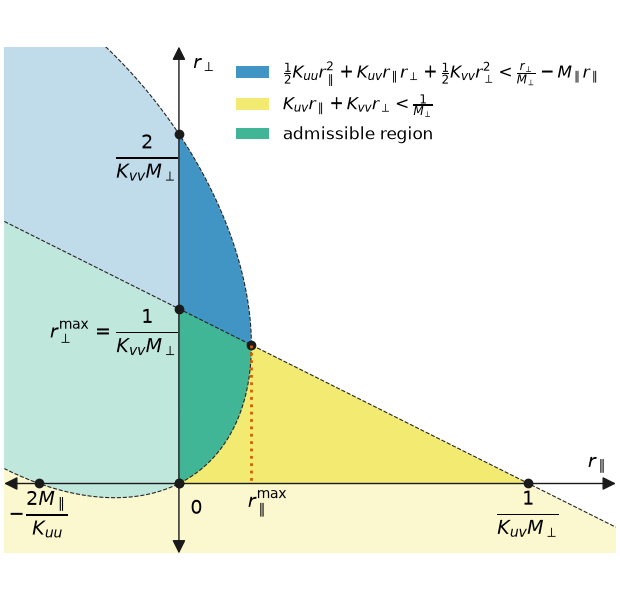

In [2]:
K_uu = 1.25
K_uv = 0.5
K_vv = 1.0
M_u = 0.25
M_v = 2.0
xlim = (-0.5, 1.25)
ylim = (-0.2, 1.25)
resolution = 1600


# Sample at pixel centers so the image matches its coordinate extent.
xe = np.linspace(*xlim, resolution + 1)
ye = np.linspace(*ylim, resolution + 1)
x = 0.5 * (xe[:-1] + xe[1:])
y = 0.5 * (ye[:-1] + ye[1:])
X, Y = np.meshgrid(x, y)

F = 0.5 * K_uu * X**2 + K_uv * X * Y + 0.5 * K_vv * Y**2 - Y / M_v + M_u * X
G = K_uv * X + K_vv * Y - 1.0 / M_v
a, b = F < 0, G < 0

fq = (X > 0) & (Y > 0)
domain = (X < 0) | (Y < 0) | fq

# Boolean mask, Okabe–Ito color, legend label.
regions = [
    (
        a & ~b,
        "#0072B2",
        r"$\frac{1}{2}K_{uu}r_\parallel^2 + K_{uv}r_\parallel r_\perp + \frac{1}{2}K_{vv}r_\perp^2 < \frac{r_\perp}{M_\perp} - M_\parallel r_\parallel$",
    ),
    (~a & b, "#F0E442", r"$K_{uv}r_\parallel + K_{vv}r_\perp < \frac{1}{M_\perp}$"),
    (a & b, "#009E73", r"admissible region"),
]

# One RGBA image avoids overlapping semi-transparent fills.
# Unassigned pixels remain fully transparent.
rgba = np.zeros((*X.shape, 4), dtype=np.float32)

for mask, color, _ in regions:
    rgba[mask & domain] = to_rgba(color)

rgba[..., 3] *= np.where(fq, 0.75, 0.25)

fig, ax = plt.subplots(figsize=(6.2, 6.0), constrained_layout=True)
fig.set_facecolor("white")
ax.set_facecolor("white")

for Z in F, G:
    if Z.min() < 0 < Z.max():
        ax.contour(
            X,
            Y,
            Z,
            levels=[0],
            colors="0.15",
            linewidths=0.8,
            linestyles="--",
            zorder=2,
        )


ax.imshow(rgba, origin="lower", extent=(*xlim, *ylim), interpolation="bicubic", aspect="equal")

x_axis = FancyArrowPatch(posA=(xlim[0], 0), posB=(xlim[1], 0), arrowstyle="<|-|>", color="0.1", mutation_scale=20, shrinkA=0, shrinkB=0)
y_axis = FancyArrowPatch(posA=(0, ylim[0]), posB=(0, ylim[1]), arrowstyle="<|-|>", color="0.1", mutation_scale=20, shrinkA=0, shrinkB=0)
ax.add_artist(x_axis)
ax.add_artist(y_axis)

ax.plot(0, 0, marker="o", color="0.1", markersize=6)
ax.annotate("0", xy=(0, 0), xytext=(0.05, -0.1), fontsize=14, ha="center", va="bottom")
ax.annotate(rf"$r_\perp$", xy=(0, ylim[1]), xytext=(0.075, ylim[1] - 0.075), fontsize=14, ha="center", va="bottom")
ax.annotate(rf"$r_\parallel$", xy=(xlim[1], 0), xytext=(xlim[1] - 0.05, 0.03), fontsize=14, ha="center", va="bottom")

ax.plot(0, 0, marker="o", color="0.1", markersize=6)
ax.plot(0, 2 / (K_vv * M_v), marker="o", color="0.1", markersize=6)
ax.plot(0, 1 / (K_vv * M_v), marker="o", color="0.1", markersize=6)
ax.plot(1 / (K_uv * M_v), 0, marker="o", color="0.1", markersize=6)
ax.plot(-2 * M_u / K_uu, 0, marker="o", color="0.1", markersize=6)

ax.annotate(r"$\dfrac{2}{K_{vv}M_{\perp}}$", xy=(0, 2 / (K_vv * M_v)), fontsize=14, ha="right", va="top")
ax.annotate(r"$r_{\perp}^{\max} = \dfrac{1}{K_{vv}M_{\perp}}$", xy=(0, 1 / (K_vv * M_v)), fontsize=14, ha="right", va="top")
ax.annotate(r"$\dfrac{1}{K_{uv}M_{\perp}}$", xy=(1 / (K_uv * M_v), -0.02), fontsize=14, ha="center", va="top")
ax.annotate(r"$-\dfrac{2M_{\parallel}}{K_{uu}}$", xy=(-2 * M_u / K_uu, -0.02), fontsize=14, ha="center", va="top")

roots = np.roots([K_uu * K_vv - K_uv**2, 2.0 * (K_uv / M_v + K_vv * M_u), -1.0 / M_v**2])
for x in roots:
    y = (1.0 / M_v - K_uv * x) / K_vv
    if x > 0.0 and y > 0.0:
        x0, y0 = x, y

ax.plot(x0, y0, marker="o", color="0.1", markersize=6)
ax.annotate(r"$r_\parallel^{\max}$", xy=(x0 + 0.05, -0.02), fontsize=14, ha="center", va="top")
ax.plot([x0, x0], [y0, 0], color="#D55E00", linewidth=2, linestyle=":")

ax.legend(
    handles=[Patch(facecolor=color, alpha=0.75, label=label) for _, color, label in regions],
    bbox_to_anchor=(1.0, 1.0),
    loc="upper right",
    frameon=False,
    fontsize=12,
)
ax.set(xlim=xlim, ylim=ylim)
ax.axis("off")

plt.savefig("../images/conic.png", dpi=600, bbox_inches="tight")
plt.show()

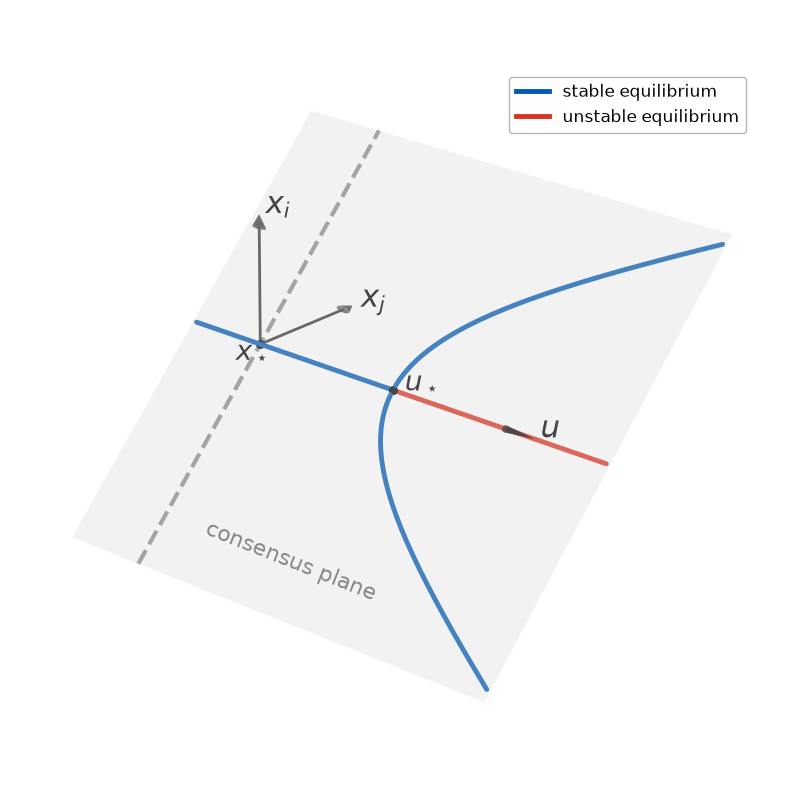

In [6]:
# ============================================================
# Parameters
# ============================================================
u_star = 1.0  # bifurcation value
u_min, u_max = -0.5, 2.50  # parameter interval shown
n_u = 1000

stable_color = "#005AB5"  # blue
unstable_color = "#DC3220"  # red
plane_color = "0.85"  # light gray
plane_alpha = 0.32


# ============================================================
# Symmetric equilibrium equation
# z = u * tanh(u * tanh(z))
# ============================================================
def F(z, u):
    return z - u * np.tanh(u * np.tanh(z))


def positive_branch(u_vals, z_cap=3.0):
    """
    Compute the positive nonzero symmetric branch z(u) > 0
    for u > u_star.
    """
    z_vals = np.full_like(u_vals, np.nan, dtype=float)

    for k, u in enumerate(u_vals):
        if u <= u_star:
            continue

        a = 1e-10
        b = z_cap
        fa = F(a, u)
        fb = F(b, u)

        if fa * fb > 0:
            found = False
            for bb in np.linspace(z_cap, 8.0, 60):
                fb = F(bb, u)
                if fa * fb < 0:
                    b = bb
                    found = True
                    break
            if not found:
                continue

        z_vals[k] = brentq(F, a, b, args=(u,))

    return z_vals


u_left = np.linspace(u_min, u_star, n_u)  # stable trivial branch
u_right = np.linspace(u_star, u_max, n_u)  # unstable trivial branch
u_side = np.linspace(u_star + 1e-3, u_max, n_u)  # stable nonzero branches

z_zero_left = np.zeros_like(u_left)
z_zero_right = np.zeros_like(u_right)

z_pos = positive_branch(u_side)
z_neg = -z_pos

mask = np.isfinite(z_pos)
u_side = u_side[mask]
z_pos = z_pos[mask]
z_neg = z_neg[mask]

# State extent chosen from actual branches so the plane contains them
state_lim = max(1.0, 1.05 * np.nanmax(np.abs(np.r_[z_pos, z_neg])))
u_plot_min = u_min - 0.025
u_plot_max = u_max + 0.025


# ============================================================
# Helpers for conical 3D axis arrowheads
# ============================================================
def orthonormal_basis(v):
    v = np.asarray(v, dtype=float)
    v = v / np.linalg.norm(v)

    if abs(v[0]) < 0.9:
        a = np.array([1.0, 0.0, 0.0])
    else:
        a = np.array([0.0, 1.0, 0.0])

    n1 = np.cross(v, a)
    n1 /= np.linalg.norm(n1)
    n2 = np.cross(v, n1)
    return v, n1, n2


def add_cone(ax, tip, direction, length=0.12, radius=0.05, color="k", n=36):
    """
    Draw a filled cone with apex at tip and axis along direction.
    """
    tip = np.asarray(tip, dtype=float)
    direction = np.asarray(direction, dtype=float)
    v, n1, n2 = orthonormal_basis(direction)

    base_center = tip - length * v
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)

    circle = np.array([base_center + radius * (np.cos(t) * n1 + np.sin(t) * n2) for t in theta])

    faces = []
    for i in range(n):
        p1 = circle[i]
        p2 = circle[(i + 1) % n]
        faces.append([tip, p1, p2])

    cone = Poly3DCollection(faces, facecolors=color, edgecolors=color, linewidths=0.0)
    ax.add_collection3d(cone)


def draw_axis_arrow(ax, start, direction, length, color="k", lw=2.2, cone_length=0.11, cone_radius=0.04):
    """
    Draw axis shaft + conical head.
    """
    start = np.asarray(start, dtype=float)
    direction = np.asarray(direction, dtype=float)
    direction = direction / np.linalg.norm(direction)

    tip = start + length * direction
    shaft_end = tip - cone_length * direction

    ax.plot(
        [start[0], shaft_end[0]],
        [start[1], shaft_end[1]],
        [start[2], shaft_end[2]],
        color=color,
        lw=lw,
        solid_capstyle="round",
    )

    add_cone(ax, tip, direction, length=cone_length, radius=cone_radius, color=color)

    return tip


# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(8.0, 8.0), dpi=100)
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# Consensus plane x_i = x_j
# In display coords: Y = Z
# parametrized as (u, s, s)
# Make it large enough to contain all branches
# ------------------------------------------------------------
U_plane = np.array([u_plot_min, u_plot_max])
S_plane = np.array([-state_lim, state_lim])
U_grid, S_grid = np.meshgrid(U_plane, S_plane)

X_plane = U_grid
Y_plane = S_grid
Z_plane = S_grid

ax.plot_surface(X_plane, Y_plane, Z_plane, color=plane_color, alpha=plane_alpha, linewidth=0, shade=False, zorder=0)

# "consensus plane" label:
# place it on the plane, near the lower-left portion, horizontal on screen
ax.text(
    .4,
    -.9 * state_lim,
    -.9 * state_lim,
    "consensus plane",
    color="0.4",
    fontsize=16,
    ha="left",
    va="center",
    zdir='x'
)

# Dashed dark-gray line (a,a,0) in original coordinates
a = np.linspace(-state_lim, state_lim, 300)
ax.plot(np.zeros_like(a), a, a, ls="--", lw=3.0, color="0.55", zorder=2)

# Equilibrium branches (u, z, z)
ax.plot(u_left, z_zero_left, z_zero_left, color=stable_color, lw=3.5, solid_capstyle="round", zorder=5)  # Stable trivial branch
ax.plot(u_right, z_zero_right, z_zero_right, color=unstable_color, lw=3.5, solid_capstyle="round", zorder=5)  # Unstable trivial branch
# Stable nonzero branches
ax.plot(u_side, z_pos, z_pos, color=stable_color, lw=3.5, solid_capstyle="round", zorder=6)
ax.plot(u_side, z_neg, z_neg, color=stable_color, lw=3.5, solid_capstyle="round", zorder=6)

# Mark origin x_* and critical point u_*
ax.scatter([0], [0], [0], color="k", s=30, zorder=10)
ax.scatter([u_star], [0], [0], color="k", s=30, zorder=10)
ax.text(-0.1, -0.25, -0.25, r"$x_\star$", fontsize=20)
ax.text(u_star+0.12, 0.1, -0.1, r"$u_\star$", fontsize=20)

# Axes from the origin (0,0,0)
u_tip = draw_axis_arrow(ax, start=(0, 0, 0), direction=(1, 0, 0), length=2, color="k", lw=2.5, cone_length=0.2, cone_radius=0.05)  # u-axis
xi_tip = draw_axis_arrow(ax, start=(0, 0, 0), direction=(0, 1, 0), length=2, color="0.2", lw=2.0, cone_length=0.2, cone_radius=0.05)  # x_i-axis
xj_tip = draw_axis_arrow(ax, start=(0, 0, 0), direction=(0, 0, 1), length=2, color="0.2", lw=2.0, cone_length=0.2, cone_radius=0.05)  # x_j-axis

# Axis labels
ax.text(u_tip[0] + 0.05, u_tip[1] + 0.05, u_tip[2], r"$u$", fontsize=22)
ax.text(xi_tip[0] + 0.05, xi_tip[1] + 0.05, xi_tip[2], r"$x_i$", fontsize=22)
ax.text(xj_tip[0] + 0.05, xj_tip[1], xj_tip[2] + 0.05, r"$x_j$", fontsize=22)

# Styling
ax.set_xlim(u_plot_min, u_plot_max)
ax.set_ylim(-state_lim, state_lim)
ax.set_zlim(-state_lim, state_lim)
ax.invert_yaxis()

ax.set_box_aspect((1.5, 1, 1))
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([]); ax.grid(False)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_visible(False)
    axis.line.set_color((1, 1, 1, 0))

# Legend: only stable/unstable branches
legend_handles = [
    Line2D([0], [0], color=stable_color, lw=3.5, label="stable equilibrium"),
    Line2D([0], [0], color=unstable_color, lw=3.5, label="unstable equilibrium"),
]
leg = ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.66, 0.95),
    frameon=True,
    framealpha=0.95,
    fontsize=12
)
leg.get_frame().set_edgecolor("0.7")


ax.view_init(elev=-44, azim=-33, roll=-66)

plt.tight_layout()
plt.savefig("../images/consensus.png", dpi=600, bbox_inches="tight")
plt.show()